In [ ]:
import torch

from qubosolver.config import EmbeddingConfig, SolverConfig
from qubosolver.solver import QUBOInstance, QuboSolver
from qoolqit import AnalogDeviceWithDMM
import matplotlib.pyplot as plt
import warnings
plt.rcParams["animation.html"] = "jshtml"
warnings.filterwarnings("ignore", module="matplotlib")

%matplotlib inline

## Embeddings

When using quantum approaches, we have to define a map from the instance variables to atoms on a quantum device. We call this step an embedding. This tutorial aims to show small code snippet on how to use the different embedding methods (`blade`, `custom`, `greedy`) as well as how to parametrize the algorithms through the `SolverConfig` according to a given QUBO matrix. 

In [ ]:
# import QUBO matrix manually
coefficients = torch.load("qubo_size_15.pt", weights_only=True)
instance = QUBOInstance(coefficients)

1. Define a `SolverConfig` to be passed to any solver

In [ ]:
config = SolverConfig(use_quantum=True)

For now, the `SolverConfig` contains parameters according to all available procedures (`pre-post processing`, `embedding`, ...). It has a default behavior that is compliant to the minimum requirements to run the workflow, as long as the given QUBO matrix fits with these default paremeters.

If one want to access to the default attributes, it is easily readable through the following:

In [ ]:
config.print_specs()

config_name: ''
use_quantum: True
embedding: {'embedding_method': <EmbedderType.GREEDY: 'greedy'>, 'draw_steps': False, 'animation_save_path': None, 'greedy_layout': <LayoutType.TRIANGULAR: <class 'pulser.register.special_layouts.TriangularLatticeLayout'>>, 'greedy_traps': -1, 'greedy_max_possible_term': ('factor', 1.0), 'greedy_density': None}
drive_shaping: {'drive_shaping_method': <DriveType.HEURISTIC: 'heuristic'>, 'dmm': True}
classical: {'classical_solver_type': 'simulated_annealing_tabu_search', 'max_iter': 100, 'max_bitstrings': 1, 'sa_initial_temp': 10.0, 'sa_final_temp': 0.1, 'sa_cooling_rate': None, 'sa_seed': None, 'sa_start': None, 'sa_energy_tol': 0.0, 'sa_time_limit': inf, 'tabu_x0': None, 'tabu_tenure': 7, 'tabu_max_no_improve': 20, 'tabu_time_limit': inf}
backend: <qubosolver.backends.LocalEmulator object at 0x7f7f565278b0>
device: AnalogDevice: 
 └── max_duration: 332.43763968
 └── max_amplitude: 0.22680411206965717
 └── max_abs_detuning: 2.268041120696572
 └── min_di

2) Define a `QuboSolver`, by passing the instance and the defined configuration

In [ ]:
solver = QuboSolver(instance, config)

3. Call the embedding method according to the provided set of parameters defined by the `SolverConfig`.

In [ ]:
register = solver.embedding()

From the chosen embedding method, we get a set of two-dimensional coordinates that should be embeddable on the register:

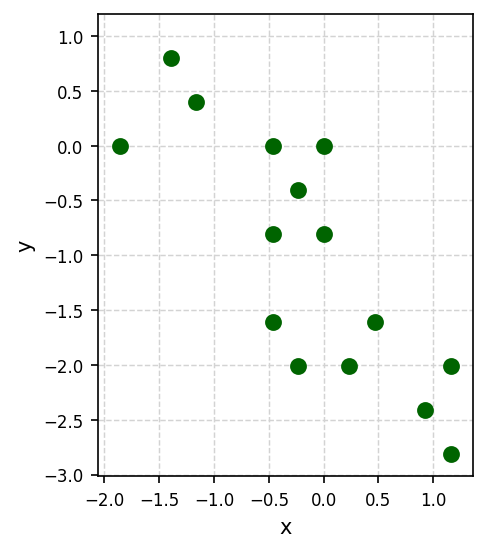

In [ ]:
register.draw()

### BLaDE parametrization
Following previous workflow, we can reiterate using a more fined parametrization of the `SolverConfig` for the `blade` embedding method.

Here is a code snippet of an arbitrary parametrization of BLaDE using multiple layers of $n$-dimension and a number of steps per round (i.e. number of iteration per layer):

/home/cterrasson/.local/share/hatch/env/virtual/qubo-solver/ZbwaPz_A/qubo-solver/lib/python3.10/site-packages/qoolqit/embedding/algorithms/blade/_helpers.py:11: RuntimeWarning: divide by zero encountered in divide
  return 1 / dist**6
/home/cterrasson/.local/share/hatch/env/virtual/qubo-solver/ZbwaPz_A/qubo-solver/lib/python3.10/site-packages/qoolqit/embedding/algorithms/blade/_helpers.py:15: RuntimeWarning: divide by zero encountered in divide
  return (1 / weight) ** (1 / 6)  # type: ignore[no-any-return]
/home/cterrasson/.local/share/hatch/env/virtual/qubo-solver/ZbwaPz_A/qubo-solver/lib/python3.10/site-packages/qoolqit/embedding/algorithms/blade/_force.py:95: RuntimeWarning: invalid value encountered in multiply
  self.weighted_vectors
/home/cterrasson/.local/share/hatch/env/virtual/qubo-solver/ZbwaPz_A/qubo-solver/lib/python3.10/site-packages/qoolqit/embedding/algorithms/blade/_force.py:88: RuntimeWarning: invalid value encountered in divide
  temperature_ratios = self.maximum_tem

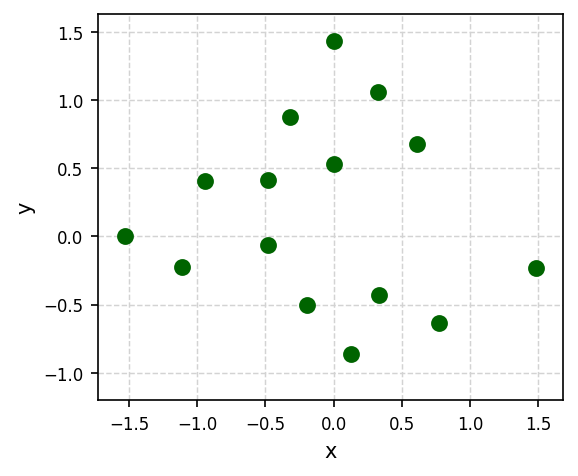

In [ ]:
blade_settings = EmbeddingConfig(embedding_method="blade", blade_dimensions=[5 ,4, 3, 2], blade_steps_per_round=300)
blade_config = SolverConfig.from_kwargs(
    use_quantum=True,
    device=AnalogDeviceWithDMM(),
    embedding=blade_settings,
)

solver = QuboSolver(instance, blade_config)
register = solver.embedding()
register.draw()

### Greedy embedder parametrization
We do the same using the `greedy` embedding method, using a triangular lattice layout on a `AnalogDeviceWithDMM` with a number of greedy_traps at least equal to the number of variables in the QUBO (with `-1` the number of traps is automatically set to the device capacity):

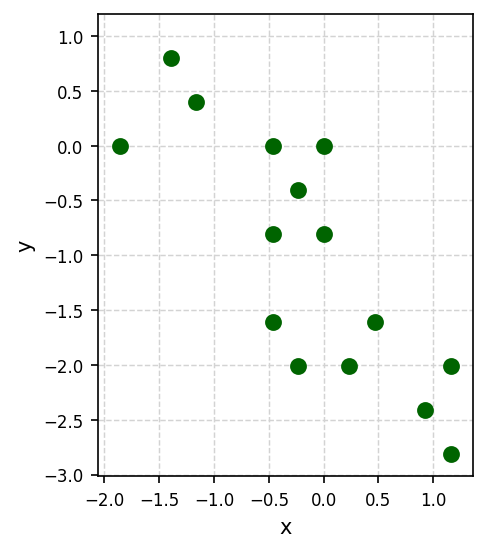

In [ ]:
greedy_settings = EmbeddingConfig(embedding_method="greedy", greedy_layout="triangular", greedy_traps=-1)

greedy_config = SolverConfig.from_kwargs(
    use_quantum=True,
    device=AnalogDeviceWithDMM(),
    embedding=greedy_settings,
)

solver = QuboSolver(instance, greedy_config)
register = solver.embedding()
register.draw()

### Custom embedder

If one desires to develop his own embedding method, a subclass of `qubosolver.pipeline.embedder.BaseEmbedder` should be implemented with a mandatory `embed` method.

The `embed` method `def embed(self) -> qoolqit.Register` specifies how the problem is mapped into a register of qubits when running using a quantum device. Let us show a simple example where each variable $i$ is mapped into a qubit lying on a horizontal line (with coordinates $[i, 0]$, $i$ normalized by the device specs).

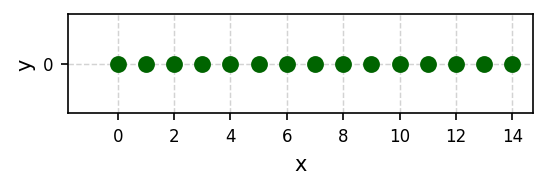

In [ ]:
import typing
from qubosolver.pipeline.embedder import BaseEmbedder
from qoolqit import Register
from qubosolver.config import SolverConfig

class FixedEmbedder(BaseEmbedder):

    @typing.no_type_check
    def embed(self) -> Register:
        # a pairwise distance of R represents a quadratic coefficient of 1/R⁶
        qubits = {f"q{i}": (i, 0) for i in range(self.instance.coefficients.shape[0])}
        register = Register(qubits)
        return register


custom_config = SolverConfig.from_kwargs(
    use_quantum=True,
    embedding_method=FixedEmbedder,
)
solver = QuboSolver(instance, custom_config)
register = solver.embedding()
register.draw()

## Greedy algorithm - Vizualisation 

In [ ]:
from qubosolver.solver import QUBOInstance, QuboSolver
from qubosolver.config import SolverConfig, EmbeddingConfig

In [ ]:
import torch

Q = torch.tensor([
    [-4.0, 1.0, 2.0, 1.5, 2.3, 0.9, 1.8, 2.7, 1.2],
    [ 1.0,-3.2, 1.7, 2.1, 0.8, 1.9, 2.2, 1.1, 1.6],
    [ 2.0, 1.7,-5.1, 0.7, 2.5, 1.3, 2.6, 1.4, 2.0],
    [ 1.5, 2.1, 0.7,-2.7, 1.2, 2.4, 0.6, 1.8, 2.1],
    [ 2.3, 0.8, 2.5, 1.2,-6.3, 1.0, 1.7, 2.8, 1.5],
    [ 0.9, 1.9, 1.3, 2.4, 1.0,-4.5, 2.3, 1.6, 0.9],
    [ 1.8, 2.2, 2.6, 0.6, 1.7, 2.3,-3.8, 1.2, 2.2],
    [ 2.7, 1.1, 1.4, 1.8, 2.8, 1.6, 1.2,-5.9, 1.4],
    [ 1.2, 1.6, 2.0, 2.1, 1.5, 0.9, 2.2, 1.4,-2.4],
], dtype=torch.float32)

instance = QUBOInstance(Q)

greedy_settings = EmbeddingConfig(
    embedding_method="greedy",
    greedy_layout="triangular",  # or "square"
    greedy_traps=instance.size + 6,
    draw_steps=True,                         # ← single toggle
    animation_save_path="greedy_demo.gif",   # ← optional file export
)

cfg = SolverConfig.from_kwargs(
    use_quantum=True,
    embedding=greedy_settings,
    device=AnalogDeviceWithDMM(),
)

solver = QuboSolver(instance, cfg)
geometry = solver.embedding()     # → inline animation + optional mp4


[anim] GIF saved to: greedy_demo.gif


The above should display an animation inline:

![Greedy Animation](greedy_demo.gif)
